In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [2]:
X , y = make_blobs(
    n_samples = 1000,
    n_features = 2,
    centers = 4,
    random_state = 42
)

<Axes: >

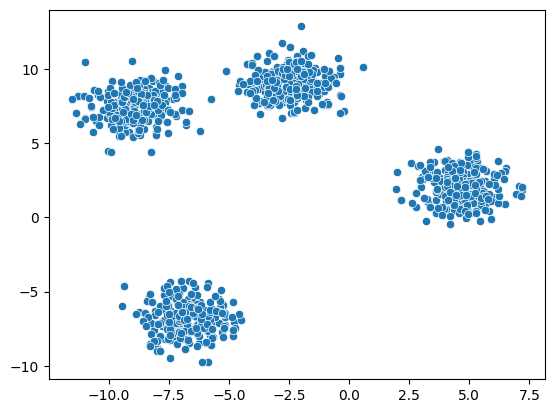

In [10]:
# Visualize Data
sns.scatterplot(x = X[:,0] , y = X[:,1] )

In [7]:
# K-Means Clustering
from sklearn.cluster import KMeans

In [9]:
K = 4

kmeans = KMeans(
    n_clusters = K,
    random_state = 42
)

labels = kmeans.fit_predict(X)
#labels = clusters number


<Axes: >

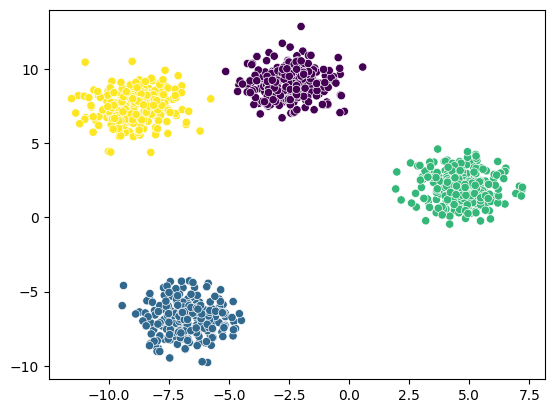

In [11]:
sns.scatterplot(x = X[:,0] , y = X[:,1] , c = labels)

# Choose our K-Value -> elbow , silhoutte score

# Elbow Method

In [12]:
# Elbow Method

wcss = []
for k in range(1 , 21):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

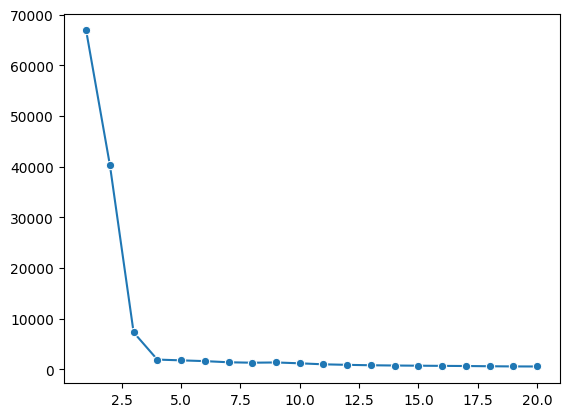

In [13]:
sns.lineplot(x = range(1 , 21) , y = wcss , marker = 'o')

In [14]:
# Kneed Module

!pip install kneed


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from kneed import KneeLocator

In [16]:
knee = KneeLocator(range(1 , 21) , wcss , curve = "convex" , direction = "decreasing")

In [19]:
print(knee.knee) # .knee / .elbow

4


# Silhouette Score

In [21]:
from sklearn.metrics import silhouette_score

In [22]:
ss = []

for k in range (2 , 21):
    kmeans = KMeans(n_clusters = k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X , labels)

    ss.append(score)

<Axes: >

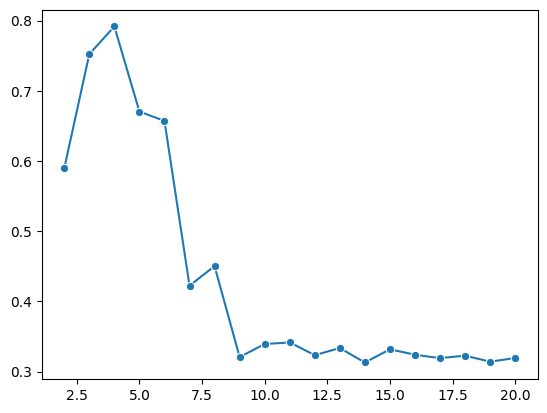

In [23]:
# PLot - X & ss
sns.lineplot(x=range(2 , 21) , y = ss , marker = 'o')